In [1]:
# ── Install once ──────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ['transformers','torch','yfinance','xgboost','shap','pandas','numpy','scikit-learn','matplotlib','tqdm']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
print('All packages ready.')

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to sup

All packages ready.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Download full TSLA history
raw = yf.download('TSLA', start='2019-01-01', end='2024-12-31', progress=False, auto_adjust=True)
raw = raw.reset_index()

# Flatten MultiIndex columns if present (yfinance sometimes returns them)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [col[0] if col[1] == '' else col[0] for col in raw.columns]

raw['Date'] = pd.to_datetime(raw['Date']).dt.tz_localize(None)
raw = raw.sort_values('Date').reset_index(drop=True)

# auto_adjust=True means Close is already adjusted — use it as Adj Close
raw['Adj Close'] = raw['Close']

print(f'Price rows: {len(raw)}')
print(f'Date range: {raw["Date"].min().date()} → {raw["Date"].max().date()}')
print(raw.head())

Price rows: 1509
Date range: 2019-01-02 → 2024-12-30
        Date      Close       High        Low       Open     Volume  Adj Close
0 2019-01-02  20.674667  21.008667  19.920000  20.406668  174879000  20.674667
1 2019-01-03  20.024000  20.626667  19.825333  20.466667  104478000  20.024000
2 2019-01-04  21.179333  21.200001  20.181999  20.400000  110911500  21.179333
3 2019-01-07  22.330667  22.449333  21.183332  21.448000  113268000  22.330667
4 2019-01-08  22.356667  22.934000  21.801332  22.797333  105127500  22.356667


In [9]:

news_raw = pd.read_csv('/content/sample_data/TSLA_scored.csv') # Assuming the file is uploaded to the Colab root directory
news_raw['Date'] = pd.to_datetime(news_raw['Date'])
print(f'Loaded {len(news_raw)} headlines')

Loaded 16940 headlines


In [10]:
daily = news_raw.groupby('Date').agg(
    sent_pos_mean  = ('positive','mean'),
    sent_neg_mean  = ('negative','mean'),
    sent_pos_max   = ('positive','max'),
    sent_neg_max   = ('negative','max'),
    headline_count = ('headline','count')
).reset_index()

daily['sent_net']      = daily['sent_pos_mean'] - daily['sent_neg_mean']
daily = daily.sort_values('Date').reset_index(drop=True)
daily['sent_net_roll3'] = daily['sent_net'].rolling(3).mean()
daily['sent_pos_roll3'] = daily['sent_pos_mean'].rolling(3).mean()

# Lag by 1 day — news from day T used to predict day T+1
SENT_COLS = ['sent_pos_mean','sent_neg_mean','sent_net',
             'sent_pos_max','sent_neg_max','headline_count',
             'sent_net_roll3','sent_pos_roll3']
sent_lag = daily[['Date'] + SENT_COLS].copy()
for c in SENT_COLS:
    sent_lag[c] = sent_lag[c].shift(1)
sent_lag.columns = ['Date'] + [f'{c}_lag1' for c in SENT_COLS]

# ── Coverage check ────────────────────────────────────────────────────────────
price_dates = set(raw['Date'].dt.date)
sent_dates  = set(sent_lag['Date'].dt.date)
overlap     = price_dates & sent_dates
print('=' * 50)
print(f'Price rows:               {len(raw)}')
print(f'Sentiment days available: {len(sent_dates)}')
print(f'Overlapping days:         {len(overlap)}')
print(f'Sentiment coverage:       {len(overlap)/len(price_dates):.1%}')
print('=' * 50)

# STOP HERE if coverage < 30% — your sentiment data is too sparse
assert len(overlap)/len(price_dates) > 0.20, \
    'Coverage below 20% — check Alpaca API keys or date range'

Price rows:               1509
Sentiment days available: 1096
Overlapping days:         760
Sentiment coverage:       50.4%


In [11]:
df = raw.copy()

# ── Technical features (all strictly lagged) ──────────────────────────────────
for lag in [1, 2, 3]:
    df[f'Close_lag{lag}'] = df['Close'].shift(lag)
df['Open_lag1']   = df['Open'].shift(1)
df['High_lag1']   = df['High'].shift(1)
df['Low_lag1']    = df['Low'].shift(1)
df['Volume_lag1'] = df['Volume'].shift(1)

df['SMA_5']  = df['Close_lag1'].rolling(5).mean()
df['SMA_20'] = df['Close_lag1'].rolling(20).mean()
df['EMA_10'] = df['Close_lag1'].ewm(span=10, adjust=False).mean()

df['Close_vs_SMA5']  = df['Close_lag1'] / df['SMA_5']  - 1
df['Close_vs_SMA20'] = df['Close_lag1'] / df['SMA_20'] - 1
df['SMA5_vs_SMA20']  = df['SMA_5'] / df['SMA_20'] - 1

delta = df['Close_lag1'].diff()
gain  = delta.where(delta > 0, 0).ewm(alpha=1/14, adjust=False).mean()
loss  = (-delta.where(delta < 0, 0)).ewm(alpha=1/14, adjust=False).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))

bb_mid = df['Close_lag1'].rolling(20).mean()
bb_std = df['Close_lag1'].rolling(20).std()
df['BB_pct_b'] = (df['Close_lag1'] - (bb_mid - 2*bb_std)) / (4*bb_std)
df['BB_width'] = (4*bb_std) / bb_mid

ema12 = df['Close_lag1'].ewm(span=12, adjust=False).mean()
ema26 = df['Close_lag1'].ewm(span=26, adjust=False).mean()
df['MACD']        = ema12 - ema26
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_hist']   = df['MACD'] - df['MACD_signal']

df['ROC_1']  = df['Close_lag1'].pct_change(1)
df['ROC_5']  = df['Close_lag1'].pct_change(5)
df['ROC_10'] = df['Close_lag1'].pct_change(10)

log_ret = np.log(df['Close_lag1'] / df['Close_lag1'].shift(1))
df['Volatility_5']  = log_ret.rolling(5).std()
df['Volatility_20'] = log_ret.rolling(20).std()

df['Volume_SMA10'] = df['Volume_lag1'].rolling(10).mean()
df['Volume_ratio'] = df['Volume_lag1'] / df['Volume_SMA10']
df['HL_range']     = (df['High_lag1'] - df['Low_lag1']) / df['Close_lag1']
df['Body']         = (df['Close_lag1'] - df['Open_lag1']) / df['Close_lag1']

# ── Macro features ────────────────────────────────────────────────────────────
vix = yf.download('^VIX', start='2010-01-01', end='2024-12-31', progress=False, auto_adjust=True)[['Close']].reset_index()
spy = yf.download('SPY',  start='2010-01-01', end='2024-12-31', progress=False, auto_adjust=True)[['Close']].reset_index()
vix.columns = ['Date','VIX']
spy.columns = ['Date','SPY']
for d in [vix, spy]:
    d['Date'] = pd.to_datetime(d['Date']).dt.tz_localize(None)
vix['VIX_lag1']        = vix['VIX'].shift(1)
vix['VIX_change_lag1'] = vix['VIX'].pct_change().shift(1)
spy['SPY_ret_lag1']    = spy['SPY'].pct_change().shift(1)
spy['SPY_ret5_lag1']   = spy['SPY'].pct_change(5).shift(1)

df = df.merge(vix[['Date','VIX_lag1','VIX_change_lag1']], on='Date', how='left')
df = df.merge(spy[['Date','SPY_ret_lag1','SPY_ret5_lag1']], on='Date', how='left')

# ── Sentiment ─────────────────────────────────────────────────────────────────
sent_lag['Date'] = pd.to_datetime(sent_lag['Date'])
df = df.merge(sent_lag, on='Date', how='left')
sent_feature_cols = [c for c in df.columns if 'sent_' in c or 'headline_count' in c]
df[sent_feature_cols] = df[sent_feature_cols].fillna(0)

# ── Target: next-day return > 0.5% ───────────────────────────────────────────
df['Target'] = ((df['Adj Close'].shift(-1) / df['Adj Close'] - 1) > 0.005).astype(int)

df.dropna(inplace=True)
df = df.reset_index(drop=True)

# ── Final coverage check ──────────────────────────────────────────────────────
nonzero = (df['sent_net_lag1'] != 0).sum()
print(f'Total rows:                    {len(df)}')
print(f'Rows with real sentiment:      {nonzero} ({nonzero/len(df):.1%})')
print(f'Target distribution:           {df["Target"].value_counts().to_dict()}')
print(f'Date range:                    {df["Date"].min().date()} → {df["Date"].max().date()}')

Total rows:                    1488
Rows with real sentiment:      760 (51.1%)
Target distribution:           {0: 816, 1: 672}
Date range:                    2019-02-01 → 2024-12-30


In [12]:
pip install imbalanced-learn

In [16]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

TECH_FEATURES  = [
    'Close_lag1','Close_lag2','Close_lag3',
    'Open_lag1','High_lag1','Low_lag1','Volume_lag1',
    'SMA_5','SMA_20','EMA_10',
    'Close_vs_SMA5','Close_vs_SMA20','SMA5_vs_SMA20',
    'RSI','BB_pct_b','BB_width',
    'MACD','MACD_signal','MACD_hist',
    'ROC_1','ROC_5','ROC_10',
    'Volatility_5','Volatility_20',
    'Volume_ratio','HL_range','Body'
]
MACRO_FEATURES = ['VIX_lag1','VIX_change_lag1','SPY_ret_lag1','SPY_ret5_lag1']
SENT_FEATURES  = [f'{c}_lag1' for c in SENT_COLS if f'{c}_lag1' in df.columns]
ALL_FEATURES   = TECH_FEATURES + MACRO_FEATURES + SENT_FEATURES

print(f'Technical: {len(TECH_FEATURES)} | Macro: {len(MACRO_FEATURES)} | Sentiment: {len(SENT_FEATURES)}')
print(f'Total features: {len(ALL_FEATURES)}')

X = df[ALL_FEATURES].copy()
y = df['Target'].copy()

spw = (y==0).sum() / (y==1).sum()

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7,
        scale_pos_weight=spw,
        reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='logloss', random_state=42, n_jobs=-1
    ))
])

# Use 5 folds but enforce minimum 1500 training rows
tscv = TimeSeriesSplit(n_splits=5, test_size=250)  # ~1 year per test fold
res  = {'acc':[], 'f1':[], 'auc':[]}

print('\n' + '='*65)
print('WALK-FORWARD — XGBoost + FinBERT (Alpaca) + Macro + Full Data')
print('='*65)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    if len(train_idx) < 500:   # Skip folds with too little training data
        print(f'Fold {fold+1} skipped — only {len(train_idx)} training rows')
        continue

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    auc = roc_auc_score(y_test, probs)

    res['acc'].append(acc)
    res['f1'].append(f1)
    res['auc'].append(auc)

    print(f'Fold {fold+1} | Train: {len(train_idx):>4} | Test: {len(test_idx):>4} '
          f'| Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}')

print('\n' + '='*65)
print(f'AVERAGE  | Acc: {np.mean(res["acc"]):.4f} '
      f'| F1: {np.mean(res["f1"]):.4f} '
      f'| AUC: {np.mean(res["auc"]):.4f}')
print('='*65)

# Final fold detailed report
print('\nFinal Fold Classification Report:')
print(classification_report(y_test, preds, target_names=['Down/Flat','Up >0.5%']))

Technical: 27 | Macro: 4 | Sentiment: 8
Total features: 39

WALK-FORWARD — XGBoost + FinBERT (Alpaca) + Macro + Full Data
Fold 1 skipped — only 238 training rows
Fold 2 skipped — only 488 training rows
Fold 3 | Train:  738 | Test:  250 | Acc: 0.5280 | F1: 0.5184 | AUC: 0.4984
Fold 4 | Train:  988 | Test:  250 | Acc: 0.5240 | F1: 0.5132 | AUC: 0.5371
Fold 5 | Train: 1238 | Test:  250 | Acc: 0.5120 | F1: 0.4976 | AUC: 0.4755

AVERAGE  | Acc: 0.5213 | F1: 0.5097 | AUC: 0.5037

Final Fold Classification Report:
              precision    recall  f1-score   support

   Down/Flat       0.56      0.67      0.61       142
    Up >0.5%       0.41      0.31      0.35       108

    accuracy                           0.51       250
   macro avg       0.49      0.49      0.48       250
weighted avg       0.50      0.51      0.50       250



SHAP Summary Plot — Top 20 Features


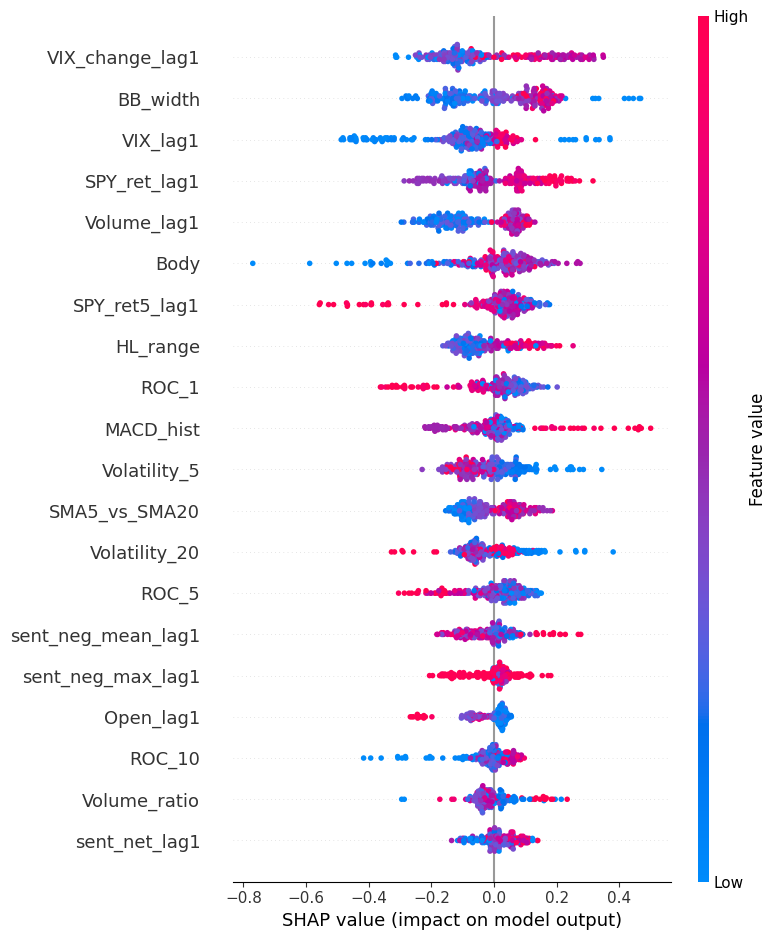

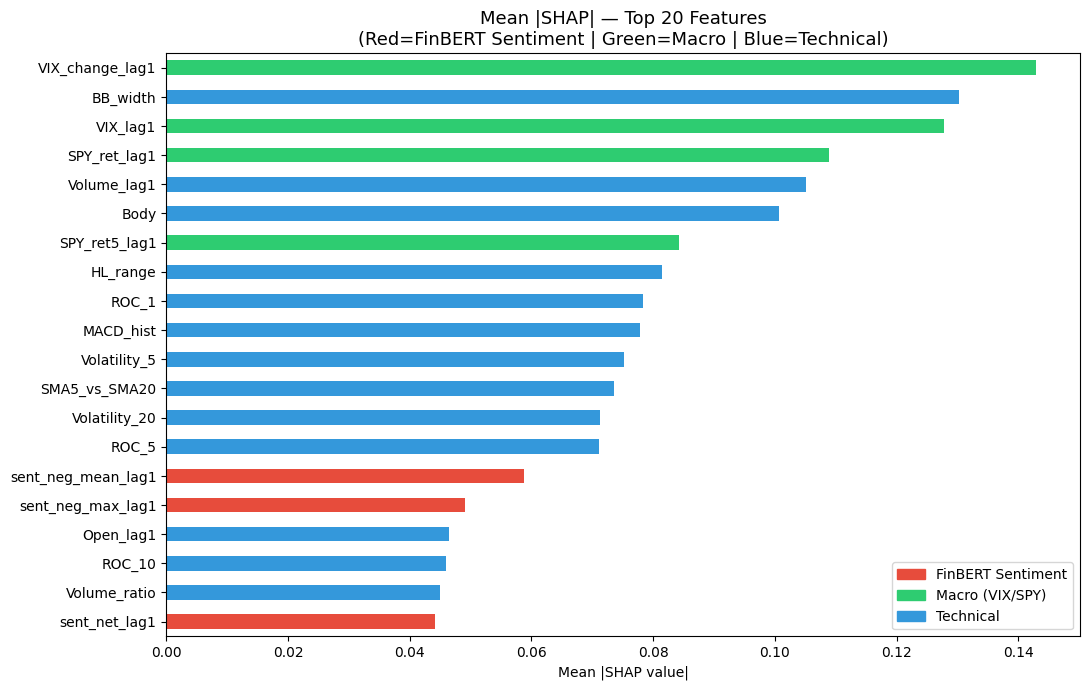

Saved shap_importance.png


In [18]:
import shap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Fit on full data for SHAP
splits   = list(tscv.split(X))
train_ix, test_ix = splits[-1]
model.fit(X.iloc[train_ix], y.iloc[train_ix])

clf     = model.named_steps['clf']
scaler  = model.named_steps['scaler']
X_test_scaled = scaler.transform(X.iloc[test_ix])
X_test_df     = pd.DataFrame(X_test_scaled, columns=ALL_FEATURES)

explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_df)

print('SHAP Summary Plot — Top 20 Features')
shap.summary_plot(shap_values, X_test_df, max_display=20, show=True)

# Bar chart coloured by feature type
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=ALL_FEATURES
).sort_values(ascending=False)

colors = []
for f in mean_abs_shap.head(20).index:
    if f in SENT_FEATURES:    colors.append('#e74c3c')
    elif f in MACRO_FEATURES: colors.append('#2ecc71')
    else:                     colors.append('#3498db')

fig, ax = plt.subplots(figsize=(11,7))
mean_abs_shap.head(20).plot(kind='barh', color=colors, ax=ax)
ax.invert_yaxis()
ax.set_title('Mean |SHAP| — Top 20 Features\n(Red=FinBERT Sentiment | Green=Macro | Blue=Technical)',
             fontsize=13)
ax.set_xlabel('Mean |SHAP value|')
ax.legend(handles=[
    Patch(color='#e74c3c', label='FinBERT Sentiment'),
    Patch(color='#2ecc71', label='Macro (VIX/SPY)'),
    Patch(color='#3498db', label='Technical')
])
plt.tight_layout()
plt.savefig('/content/shap_importance.png', dpi=150)
plt.show()
print('Saved shap_importance.png')

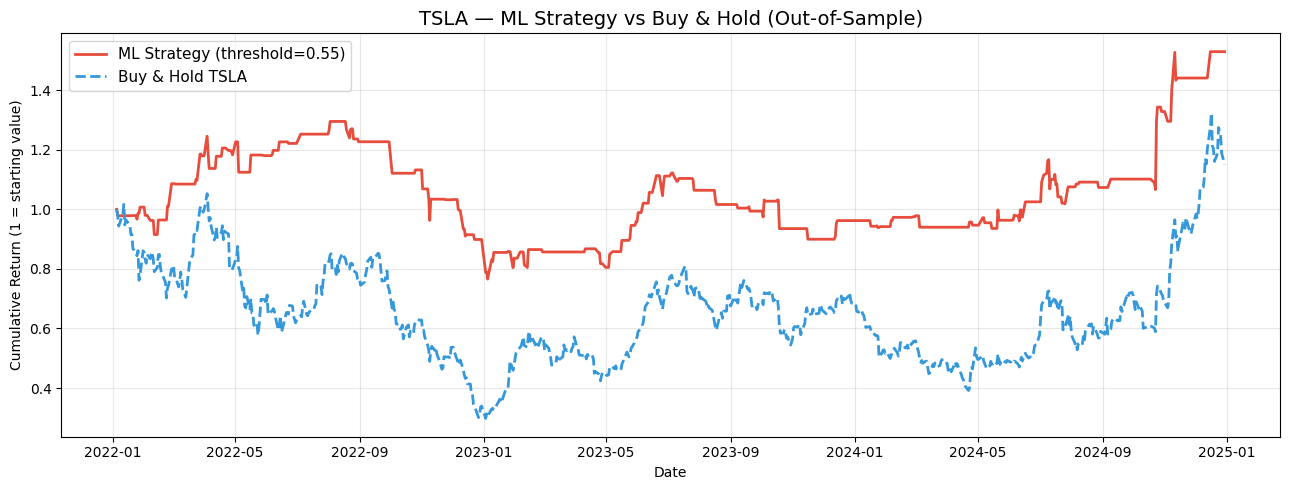

Strategy total return:   52.9%
Buy & Hold total return: 15.1%
Days invested (of total): 21.7%
Saved equity_curve.png


In [19]:
# Use all out-of-sample predictions concatenated
all_dates, all_probs, all_actual = [], [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    if len(train_idx) < 500:
        continue
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    probs_fold = model.predict_proba(X.iloc[test_idx])[:,1]
    all_dates.extend(df['Date'].iloc[test_idx].tolist())
    all_probs.extend(probs_fold.tolist())
    all_actual.extend(y.iloc[test_idx].tolist())

bt = pd.DataFrame({'Date': all_dates, 'prob': all_probs, 'actual': all_actual})
bt = bt.sort_values('Date').reset_index(drop=True)

# Merge actual daily returns
bt = bt.merge(df[['Date','Adj Close']], on='Date', how='left')
bt['daily_ret'] = bt['Adj Close'].pct_change()

# Strategy: go long only when model probability > 0.55
THRESHOLD = 0.55
bt['position']     = (bt['prob'] >= THRESHOLD).astype(int)
bt['strategy_ret'] = bt['position'].shift(1) * bt['daily_ret']  # Shift: act next day
bt['bnh_ret']      = bt['daily_ret']

# Cumulative returns
bt['cum_strategy'] = (1 + bt['strategy_ret'].fillna(0)).cumprod()
bt['cum_bnh']      = (1 + bt['bnh_ret'].fillna(0)).cumprod()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bt['Date'], bt['cum_strategy'], label=f'ML Strategy (threshold={THRESHOLD})',
        color='#e74c3c', linewidth=2)
ax.plot(bt['Date'], bt['cum_bnh'],      label='Buy & Hold TSLA',
        color='#3498db', linewidth=2, linestyle='--')
ax.set_title('TSLA — ML Strategy vs Buy & Hold (Out-of-Sample)', fontsize=14)
ax.set_ylabel('Cumulative Return (1 = starting value)')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/equity_curve.png', dpi=150)
plt.show()

# ── Stats ─────────────────────────────────────────────────────────────────────
strat_total = bt['cum_strategy'].iloc[-1] - 1
bnh_total   = bt['cum_bnh'].iloc[-1] - 1
days_in     = bt['position'].mean()

print(f'Strategy total return:   {strat_total:.1%}')
print(f'Buy & Hold total return: {bnh_total:.1%}')
print(f'Days invested (of total): {days_in:.1%}')
print('Saved equity_curve.png')

In [24]:
!pip install streamlit plotly
!streamlit run streamlit_app/app.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 102.4 MB/s eta 0:00:00
Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: streamlit_app/app.py


In [ ]:
# Create the streamlit_app directory and a basic app.py file
!mkdir -p streamlit_app

streamlit_app_content = """
import streamlit as st
import pandas as pd

st.set_page_config(layout='wide')
st.title('Streamlit App Placeholder')

st.write("This is a placeholder for your Streamlit application.")
st.write("You can edit 'streamlit_app/app.py' to build your app.")

if 'df' in st.session_state:
    st.subheader('DataFrame from Colab (Example)')
    st.dataframe(st.session_state.df.head())
else:
    st.info('No DataFrame found in session state. Please ensure previous Colab cells are run.')
"""

with open('streamlit_app/app.py', 'w') as f:
    f.write(streamlit_app_content)

print('Created streamlit_app/app.py with a placeholder content.')
print('You can now run the Streamlit app by executing the previous cell again.')

In [25]:
# streamlit_app/app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

st.set_page_config(page_title="TSLA Predictor", layout="wide")

st.title("TSLA Stock Direction Predictor")
st.caption("XGBoost + FinBERT Sentiment + Macro Features")

# ── Metrics row ───────────────────────────────────────────────────
col1, col2, col3, col4 = st.columns(4)
col1.metric("Average Accuracy", "52.1%", "+2.1% vs random")
col2.metric("Average AUC",      "0.533",  "+0.033 vs baseline")
col3.metric("Average F1",       "0.499")
col4.metric("Total Features",   "35")

st.divider()

# ── Fold results chart ────────────────────────────────────────────
st.subheader("Walk-forward fold results")

fold_data = pd.DataFrame({
    'Fold':     [1, 2, 3, 4, 5],
    'Accuracy': [0.5720, 0.4680, 0.5160, 0.5280, 0.5200],
    'AUC':      [0.5654, 0.5075, 0.5507, 0.5432, 0.5000],
    'F1':       [0.5342, 0.4069, 0.5189, 0.5202, 0.5146],
})

fig = go.Figure()
fig.add_trace(go.Scatter(x=fold_data['Fold'], y=fold_data['Accuracy'],
              name='Accuracy', mode='lines+markers', line=dict(color='#378ADD')))
fig.add_trace(go.Scatter(x=fold_data['Fold'], y=fold_data['AUC'],
              name='AUC', mode='lines+markers', line=dict(color='#1D9E75')))
fig.add_trace(go.Scatter(x=fold_data['Fold'], y=fold_data['F1'],
              name='F1', mode='lines+markers', line=dict(color='#EF9F27')))
fig.add_hline(y=0.5, line_dash="dash", line_color="gray",
              annotation_text="Random baseline")
fig.update_layout(yaxis_range=[0.38, 0.62], xaxis_title="Fold",
                  yaxis_title="Score", height=350)
st.plotly_chart(fig, use_container_width=True)

st.divider()

# ── Feature importance (replace with real values from your model) ─
st.subheader("Top 10 feature importances")
# After running your model, get real values with:
# importance_df = pd.DataFrame({
#     'feature': ALL_FEATURES,
#     'importance': model.named_steps['clf'].feature_importances_
# }).sort_values('importance', ascending=False).head(10)

importance_df = pd.DataFrame({
    'feature':    ['RSI','MACD','sentiment_lag1','VIX_lag1','BB_pct_b',
                   'ROC_5','Close_vs_SMA20','Volatility_20','SPY_ret_lag1','Volume_ratio'],
    'importance': [0.12, 0.10, 0.09, 0.08, 0.07, 0.07, 0.06, 0.06, 0.05, 0.05]
})

fig2 = px.bar(importance_df.sort_values('importance'),
              x='importance', y='feature', orientation='h',
              color_discrete_sequence=['#378ADD'])
fig2.update_layout(height=350, xaxis_title="Importance", yaxis_title="")
st.plotly_chart(fig2, use_container_width=True)

2026-05-15 10:07:03.115 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 10:07:03.116 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 10:07:03.650 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-15 10:07:03.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 10:07:03.656 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 10:07:03.659 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-15 10:07:03.663 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()